In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import dask.array as da
import os
from pycontrails.core import GeoVectorDataset
from pycontrails.models.gpat.gpat import GPAT, create_jobs_df, filter_jobs_df, load_fl_df, load_pl_df, load_chem_ds, plot_heatmap, anim_chem, mc_test, boxm_test

In [2]:
outputs_dir = f"{os.getcwd()}/outputs/"

In [3]:
# Filter criteria
criteria = {
        "n_ac": 1,
        "rt_fl": (pd.Timedelta(minutes=30), pd.Timedelta(hours=2)),
    }

In [4]:
jobs_df = create_jobs_df(outputs_dir)

jobs_df

,t0_fl,rt_fl,ts_fl,ac_type,fl0_speed,fl0_heading,fl0_coords0,sep_dist,n_ac,dt_integration,...,alt_bounds,hres_sim,vres_sim,eastward_wind,northward_wind,lagrangian_tendency_of_air_pressure,species_in,species_out,date_created,species_out_num
job_id,,,,,,,,,,,,,,,,,,,,,
954313,2022-01-20 13:00:00,0 days 01:00:00,0 days 00:02:00,A320,100.0,45.0,"(0.1, 0.125, 12500)","(5000, 2000, 0)",1,0 days 00:02:00,...,"(12000, 13000)",0.05,500,0.0,0.0,0.0,"[NO, NO2, CO]","[O3, NO2, NO, NO3, HNO3, PAN, HONO, HO2, OH, H...",2024-11-14 18:17:25.743726,"[6, 4, 8, 5, 14, 198, 13, 9, 3, 12, 11, 39, 21]"


In [5]:
filtered_df = filter_jobs_df(jobs_df, criteria)

job_ids = filtered_df.index.values

job_ids

array(['954313'], dtype=object)

In [6]:
fl_df = load_fl_df(job_ids, outputs_dir)

fl_df

plume_time_data = GeoVectorDataset(data=fl_df.loc[fl_df["time"] == fl_df["time"].min()])



In [7]:
pl_df = load_pl_df(job_ids, outputs_dir)
pl_df.columns

pl_df

,flight_id,waypoint,fuel_flow,true_airspeed,CO2,H2O,SO2,NO,NO2,CO,...,longitude,latitude,level,width,heading,sigma_yy,sigma_zz,sin_a,cos_a,altitude
job_id,,,,,,,,,,,,,,,,,,,,,
954313,0.0,0,1.180701,100.230014,447.721802,174.271461,0.119015,2.048795,0.107831,0.062205,...,0.125000,0.100000,178.645172,83.609285,NaN,8.738141e+02,544.404306,NaN,NaN,12500.0
954313,0.0,0,1.180701,100.230014,447.721802,174.271461,0.119015,2.048795,0.107831,0.062205,...,0.125000,0.100000,178.645172,154.997098,44.997927,3.003013e+03,776.308612,0.707081,0.707132,12500.0
954313,0.0,1,1.180787,100.229809,447.754616,174.284233,0.119023,2.049022,0.107843,0.062205,...,0.201229,0.176736,178.645172,83.605381,44.997927,8.737325e+02,544.234298,0.707081,0.707132,12500.0
954313,0.0,0,1.180701,100.230014,447.721802,174.271461,0.119015,2.048795,0.107831,0.062205,...,0.125000,0.100000,178.645172,242.783522,44.998098,7.367980e+03,1008.212918,0.707083,0.707130,12500.0
954313,0.0,1,1.180787,100.229809,447.754616,174.284233,0.119023,2.049022,0.107843,0.062205,...,0.201229,0.176736,178.645172,154.980249,44.997927,3.002360e+03,775.968595,0.707081,0.707132,12500.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
954313,0.0,9,1.181578,100.230606,448.054324,174.400892,0.119103,2.051106,0.107953,0.062210,...,0.811084,0.790613,178.645172,13946.764724,44.990574,2.431403e+07,13926.444916,0.706990,0.707223,12500.0
954313,0.0,10,1.181578,100.230606,448.054324,174.400892,0.119103,2.051106,0.107953,0.062210,...,0.887331,0.867340,178.645172,13599.093916,44.990574,2.311692e+07,13691.170554,0.706990,0.707223,12500.0
954313,0.0,9,1.181578,100.230606,448.054324,174.400892,0.119103,2.051106,0.107953,0.062210,...,0.811084,0.790613,178.645172,14295.156209,44.991162,2.554394e+07,14157.189745,0.706998,0.707216,12500.0


<xarray.DataArray 'emi' ()> Size: 8B
array(793)
TS: 1, Time: 2022-01-20 12:00:00, EMI: 0.0
TS: 2, Time: 2022-01-20 12:00:20, EMI: 0.0
TS: 3, Time: 2022-01-20 12:00:40, EMI: 0.0
TS: 4, Time: 2022-01-20 12:01:00, EMI: 0.0
TS: 5, Time: 2022-01-20 12:01:20, EMI: 0.0
TS: 6, Time: 2022-01-20 12:01:40, EMI: 0.0
TS: 7, Time: 2022-01-20 12:02:00, EMI: 0.0
TS: 8, Time: 2022-01-20 12:02:20, EMI: 0.0
TS: 9, Time: 2022-01-20 12:02:40, EMI: 0.0
TS: 10, Time: 2022-01-20 12:03:00, EMI: 0.0
TS: 11, Time: 2022-01-20 12:03:20, EMI: 0.0
TS: 12, Time: 2022-01-20 12:03:40, EMI: 0.0
TS: 13, Time: 2022-01-20 12:04:00, EMI: 0.0
TS: 14, Time: 2022-01-20 12:04:20, EMI: 0.0
TS: 15, Time: 2022-01-20 12:04:40, EMI: 0.0
TS: 16, Time: 2022-01-20 12:05:00, EMI: 0.0
TS: 17, Time: 2022-01-20 12:05:20, EMI: 0.0
TS: 18, Time: 2022-01-20 12:05:40, EMI: 0.0
TS: 19, Time: 2022-01-20 12:06:00, EMI: 0.0
TS: 20, Time: 2022-01-20 12:06:20, EMI: 0.0
TS: 21, Time: 2022-01-20 12:06:40, EMI: 0.0
TS: 22, Time: 2022-01-20 12:07:00, EM

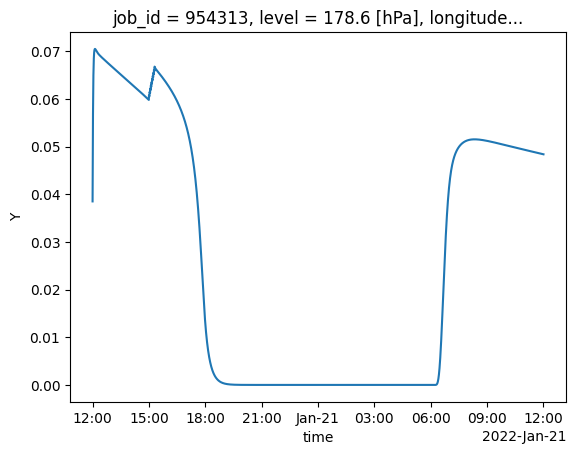

In [15]:
chem_ds = load_chem_ds(job_ids, outputs_dir)

chem_ds = chem_ds.assign_coords(species_out=chem_ds.attrs["species_out"])

chem_ds_stacked = chem_ds.stack(
            {"cell": ["level", "longitude", "latitude"]}
        )
chem_ds_stacked = chem_ds_stacked.reset_index("cell")

max_emi_cell = chem_ds_stacked["emi"].mean(dim="time").argmax()#.item()
print(max_emi_cell)
# find cell that has max emissions averaged over time in it
cell_chem_ds = chem_ds.sel(job_id=job_ids[0], longitude=0.8, latitude=0.1).sel(level=178.6, method="nearest")
cell_chem_ds["emi"].sel(emi_species="CO")

# Select the emissions for the specified species
emi_data = cell_chem_ds["emi"].sel(emi_species="NO")
chem_data = cell_chem_ds["Y"].sel(species_out="NO")
#emi_data.plot()
chem_data.plot()

# Convert time and emi data to pandas Series
ts = 0
time_series = pd.Series(emi_data["time"].values)
emi_series = pd.Series(emi_data.values)

# Print time and emi values side by side
for time, emi in zip(time_series, emi_series):
    ts += 1
    print(f"TS: {ts}, Time: {time}, EMI: {emi}")


In [9]:
#anim_chem(job_ids[0], jobs_df, fl_df, pl_df, chem_ds, var1="Y", var2="NO", level=178.6, resample_freq="2min")

In [10]:
vecmass, gridmass, mc = mc_test(job_ids[0], jobs_df, fl_df, pl_df, chem_ds)
mc

,NO,NO2,CO,HCHO,CH3CHO,C2H4,C3H6,C2H2,BENZENE
2022-01-20 13:00:00,0.000000,0.000000,0.000000,0,0,0,0,0,0
2022-01-20 13:02:00,98.761044,98.761044,98.756050,0,0,0,0,0,0
2022-01-20 13:04:00,97.679255,97.679255,97.674278,0,0,0,0,0,0
2022-01-20 13:06:00,98.296510,98.296510,98.291315,0,0,0,0,0,0
2022-01-20 13:08:00,96.993656,96.993656,96.988649,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...
2022-01-20 15:08:00,99.941836,99.941836,99.939381,0,0,0,0,0,0
2022-01-20 15:10:00,99.950724,99.950724,99.948862,0,0,0,0,0,0
2022-01-20 15:12:00,99.967066,99.967066,99.965811,0,0,0,0,0,0
2022-01-20 15:14:00,99.982415,99.982415,99.981781,0,0,0,0,0,0


In [11]:
cell_chem_ds = boxm_test(job_ids[0], 793, chem_ds)

start_time = pd.to_datetime(cell_chem_ds["time"].values[0])
end_time = pd.to_datetime(cell_chem_ds["time"].values[-1])
runtime = int((end_time - start_time) / np.timedelta64(1, 'D')) % 365

start_time, end_time, runtime

FileNotFoundError: [Errno 2] No such file or directory: 'boxm_orig'